# Resume Screening System using NLP & Machine Learning

## Complete End-to-End Project

This notebook performs the **entire machine-learning and NLP workflow** for the Resume Screening System:

1. Load and validate the Kaggle dataset
2. Exploratory Data Analysis
3. NLP preprocessing
4. Text statistics and word cloud
5. Stratified train/test split
6. TF-IDF feature extraction
7. Train multiple ML models
8. Compare Accuracy, Precision, Recall and F1
9. Confusion matrix
10. 5-fold cross-validation
11. Feature interpretation
12. Save the final model and TF-IDF vectorizer
13. Test resume prediction
14. PDF resume extraction
15. Skill extraction
16. Generate a screening result
17. Prepare artifacts used by the Streamlit app

In [1]:
from pathlib import Path
import re
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


!python -m spacy download en_core_web_sm -q
import spacy
import nltk

nlp = spacy.load("en_core_web_sm")

df = pd.read_csv("Resume/Resume.csv")


RANDOM_STATE = 42
TEST_SIZE = 0.20

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Load and Validate the Dataset

In [2]:
print("Dataset information:")
display(df.info())

print("\nCategory distribution:")
category_counts = (
    df["Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Count")
)

display(category_counts)

print("\nBasic statistics:")
display(df.describe(include="all").T)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


None


Category distribution:


,Category,Count
0,INFORMATION-TECHNOLOGY,120
1,BUSINESS-DEVELOPMENT,120
2,ADVOCATE,118
3,CHEF,118
4,ENGINEERING,118
5,ACCOUNTANT,118
6,FINANCE,118
7,FITNESS,117
8,AVIATION,117
9,SALES,116



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2484.0,NaN,NaN,NaN,31826159.293881,21457345.620455,3547447.0,17544295.5,25210313.0,36114441.0,99806115.0
Resume_str,2484,2482,STOREKEEPER II Professional Sum...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Resume_html,2484,2482,"<div class=""fontsize fontface vmargins hmargin...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2484,24,INFORMATION-TECHNOLOGY,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Total rows:", len(df))
print("Duplicate resumes:", df["Resume_str"].duplicated().sum())
print("Unique resumes:", df["Resume_str"].nunique())

Total rows: 2484
Duplicate resumes: 2
Unique resumes: 2482


In [7]:
df = df.drop_duplicates(
    subset=["Resume_str"]
).reset_index(drop=True)

In [8]:
print("Duplicate resumes:", df["Resume_str"].duplicated().sum())

Duplicate resumes: 0


## 2. Exploratory Data Analysis

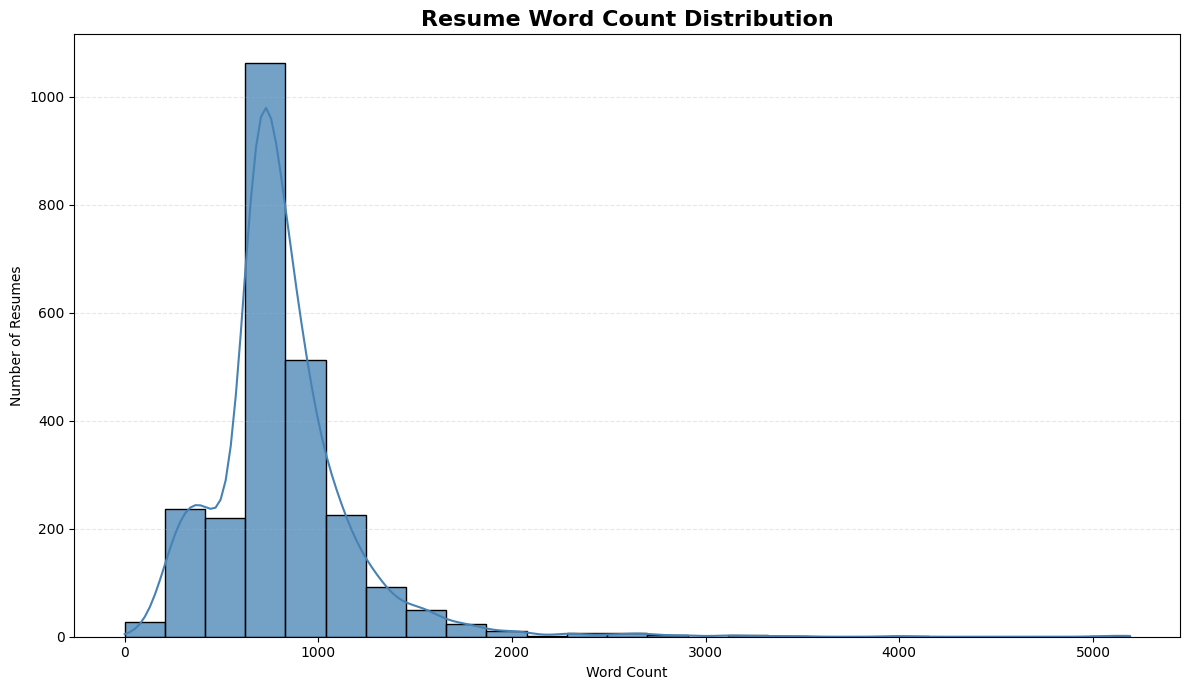

In [9]:
df["word_count"] = df["Resume_str"].str.split().str.len()

plt.figure(figsize=(12, 7))

sns.histplot(
    df["word_count"],
    bins=25,
    kde=True,
    color="steelblue",
    edgecolor="black",
    alpha=0.75
)

plt.title(
    "Resume Word Count Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Word Count")
plt.ylabel("Number of Resumes")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 3. NLP Preprocessing

The preprocessing is intentionally conservative.

Resume data contains technical tokens such as:

- C++
- C#
- .NET
- Node.js
- Python
- AWS
- SQL

Over-aggressive cleaning can destroy useful information.

In [12]:
nltk.download("stopwords", quiet=True)

from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\b[\w.+-]+@[\w-]+\.[\w.-]+\b", " ", text)
    text = re.sub(r"[^a-z0-9+#.\s]", " ", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_text(text):
    text = clean_text(text)
    doc = nlp(text)

    words = [
        token.lemma_
        for token in doc
        if token.text not in STOP_WORDS
        and token.text not in {"c", "r", "go"}
        and not token.is_punct
        and token.lemma_.strip()
    ]

    return " ".join(words)


df["clean_resume"] = df["Resume_str"].apply(preprocess_text)
df["word_count_clean"] = df["clean_resume"].str.split().str.len()

display(
    df[["Category", "Resume_str", "clean_resume"]].head(5)
)

,Category,Resume_str,clean_resume
0,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,HR,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist we hr operation summary versatil...
2,HR,HR DIRECTOR Summary Over 2...,hr director summary 20 year experience recruit...
3,HR,HR SPECIALIST Summary Dedica...,hr specialist summary dedicate driven dynamic ...
4,HR,HR MANAGER Skill Highlights ...,hr manager skill highlight hr skill hr departm...


,Word,Frequency
0,state,16295
1,company,15712
2,city,15107
3,management,12162
4,name,11776
5,customer,11321
6,service,9059
7,work,8594
8,sale,8525
9,skill,8134


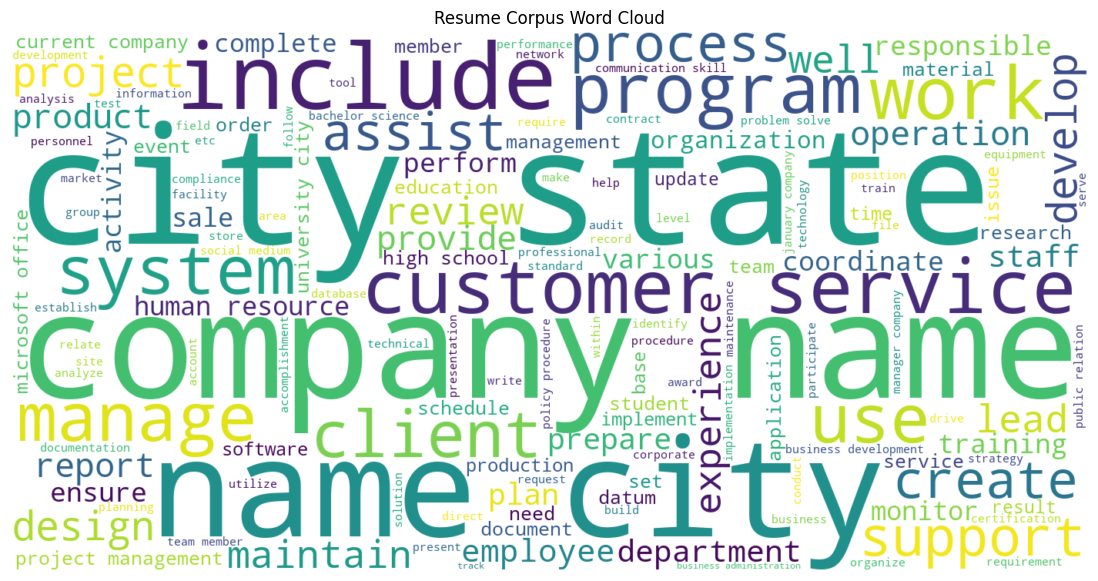

In [13]:
from collections import Counter
from wordcloud import WordCloud

all_words = " ".join(df["clean_resume"]).split()
word_counter = Counter(all_words)

common_words = pd.DataFrame(
    word_counter.most_common(40),
    columns=["Word", "Frequency"]
)

display(common_words)

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    max_words=150
).generate(" ".join(df["clean_resume"]))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Resume Corpus Word Cloud")
plt.show()

## 4. Train/Test Split

A stratified split is used because the category distribution is uneven.

**Important:** TF-IDF is fitted only on the training set to avoid data leakage.

In [14]:
from sklearn.model_selection import train_test_split

X = df["clean_resume"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1985
Testing samples: 497


## 5. TF-IDF Feature Extraction

We use:

- `max_features=15000`
- unigrams + bigrams
- `min_df=2`
- sublinear TF scaling

This allows the model to learn both individual terms and useful phrases such as `machine learning`, `data science`, and `software engineer`.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF matrix:", X_train_tfidf.shape)
print("Testing TF-IDF matrix:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.get_feature_names_out()))

Training TF-IDF matrix: (1985, 15000)
Testing TF-IDF matrix: (497, 15000)
Vocabulary size: 15000


## 6. Train Multiple Machine Learning Models

In [20]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=2500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

trained_models = {}
results = []

for name, model in models.items():

    start = time.perf_counter()

    model.fit(X_train_tfidf, y_train)

    predictions = model.predict(X_test_tfidf)

    training_time = time.perf_counter() - start

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro Precision": precision_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_test, predictions,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            y_test, predictions,
            average="weighted",
            zero_division=0
        ),
        "Training Time (seconds)": training_time
    })

    trained_models[name] = model

metrics_df = pd.DataFrame(results).sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

In [19]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode labels only for XGBoost
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start = time.perf_counter()

xgb_model.fit(X_train_tfidf, y_train_xgb)

xgb_predictions_encoded = xgb_model.predict(X_test_tfidf)

training_time = time.perf_counter() - start

# Convert predictions back to original category names
xgb_predictions = label_encoder.inverse_transform(
    xgb_predictions_encoded.astype(int)
)

results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_predictions),
    "Macro Precision": precision_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, xgb_predictions,
        average="weighted",
        zero_division=0
    ),
    "Training Time (seconds)": training_time
})

trained_models["XGBoost"] = xgb_model

In [21]:
# Combine results from all models
metrics_df = pd.DataFrame(results).sort_values(
    "Macro F1",
    ascending=False
).reset_index(drop=True)

# Display all model results
display(
    metrics_df.style.format({
        "Accuracy": "{:.2%}",
        "Macro Precision": "{:.2%}",
        "Macro Recall": "{:.2%}",
        "Macro F1": "{:.2%}",
        "Weighted F1": "{:.2%}",
        "Training Time (seconds)": "{:.2f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds)
0,Random Forest,73.44%,75.44%,68.28%,67.33%,71.59%,1.80
1,Linear SVM,70.02%,69.58%,66.47%,66.09%,68.85%,0.58
2,Logistic Regression,65.19%,63.95%,62.18%,60.96%,63.46%,1.45
3,Naive Bayes,54.73%,52.82%,49.51%,45.47%,49.97%,0.02


In [22]:
xgb_results = pd.DataFrame([{
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_predictions),
    "Macro Precision": precision_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_test, xgb_predictions,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, xgb_predictions,
        average="weighted",
        zero_division=0
    ),
    "Training Time (seconds)": training_time
}])

display(
    xgb_results.style.format({
        "Accuracy": "{:.2%}",
        "Macro Precision": "{:.2%}",
        "Macro Recall": "{:.2%}",
        "Macro F1": "{:.2%}",
        "Weighted F1": "{:.2%}",
        "Training Time (seconds)": "{:.2f}"
    })
)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (seconds)
0,XGBoost,80.48%,82.01%,77.65%,78.15%,79.78%,1.80


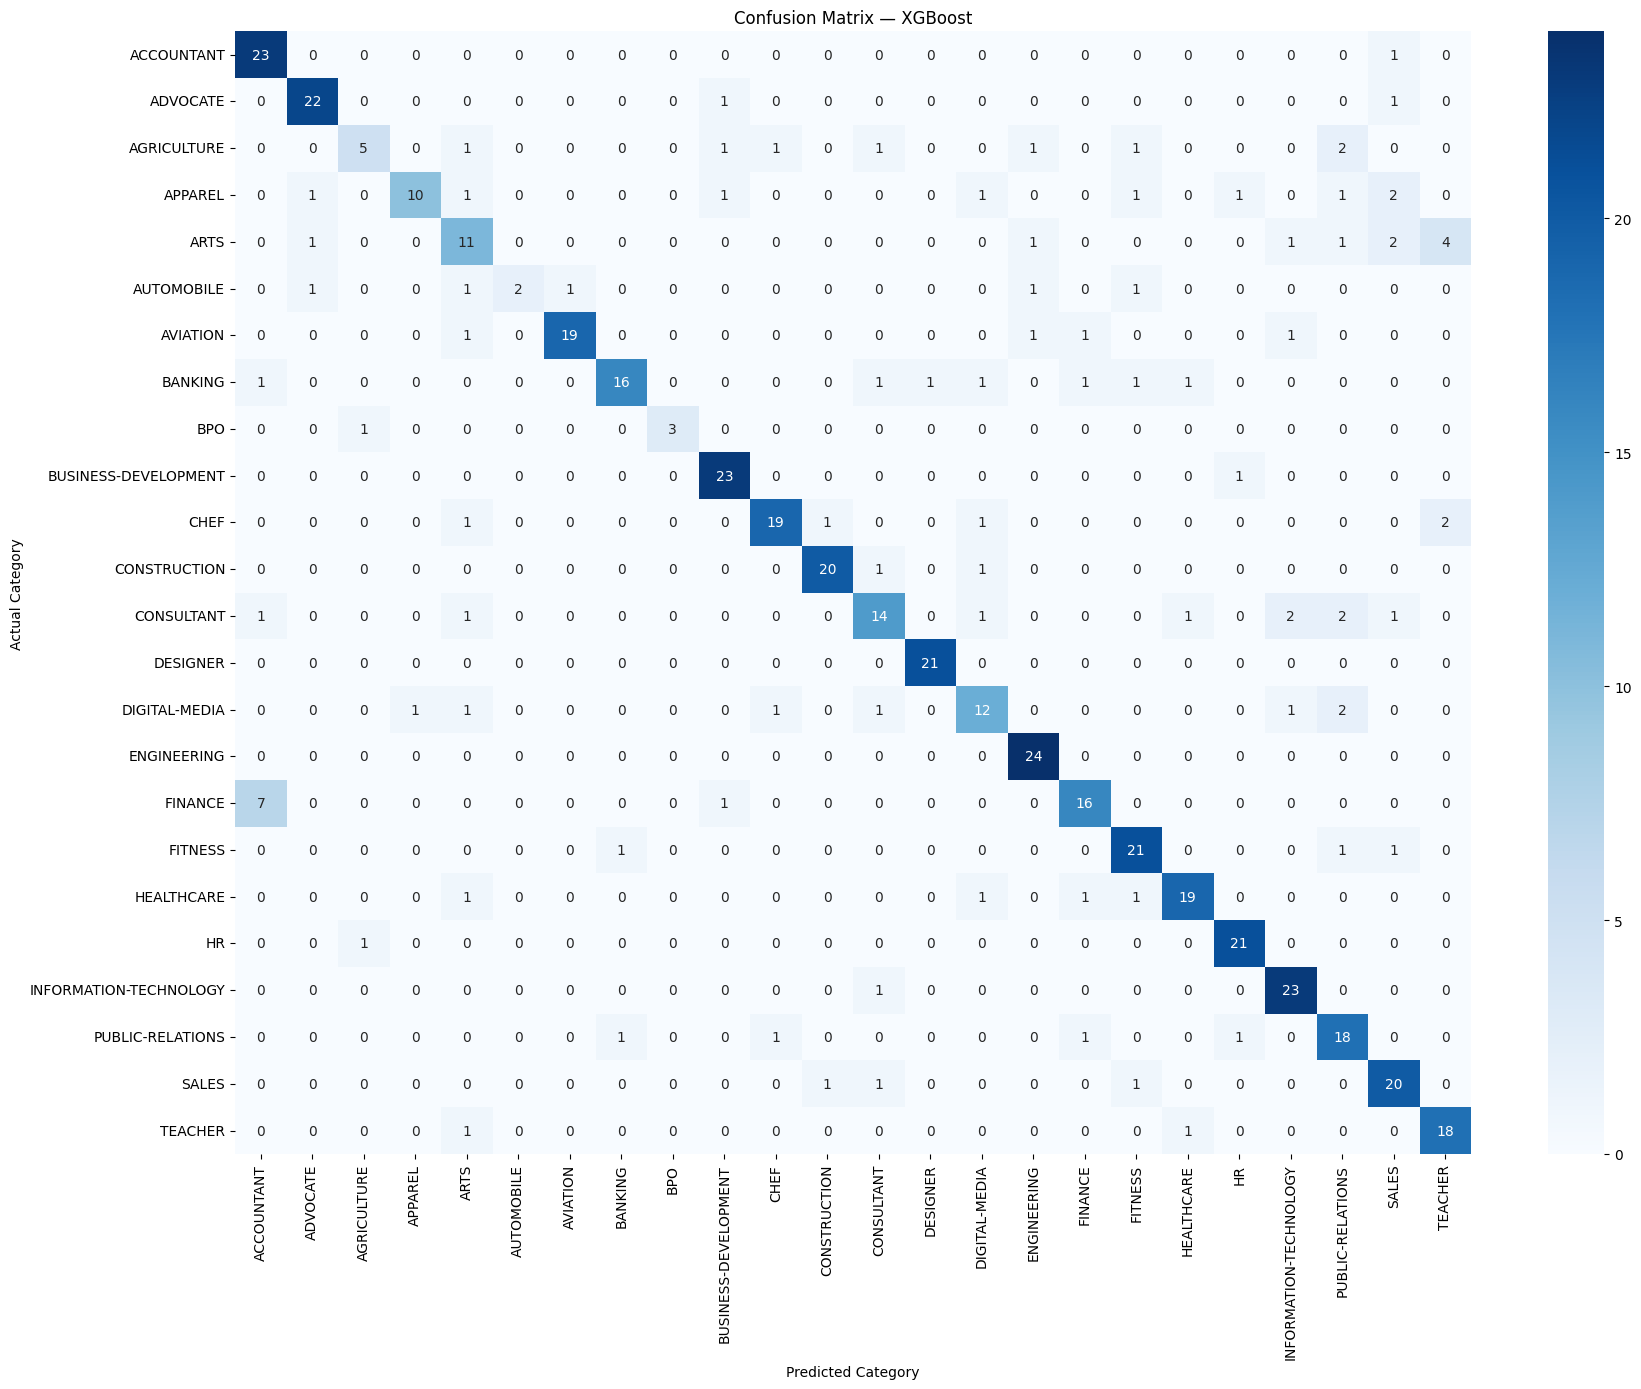

In [24]:
from sklearn.metrics import confusion_matrix

# Predict using XGBoost
best_predictions_encoded = xgb_model.predict(X_test_tfidf)

# Convert numeric predictions back to category names
best_predictions = label_encoder.inverse_transform(
    best_predictions_encoded.astype(int)
)

labels = sorted(y.unique())

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=labels
)

fig = plt.figure(figsize=(18, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix — XGBoost")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()
plt.close(fig)

## 9. Feature Interpretation

For linear models such as Linear SVM or Logistic Regression, coefficients can be used to inspect highly associated terms.

If Random Forest or Naive Bayes is selected, the notebook reports that coefficient-based interpretation is unavailable.

In [26]:
feature_names = tfidf.get_feature_names_out()

if hasattr(xgb_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": xgb_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    print("Top features overall:")

    display(feature_importance.head(30))

Top features overall:


,Feature,Importance
1161,advocate summary,0.006181
1160,advocate professional,0.005565
1363,animal,0.005159
892,accountant,0.004349
1563,art teacher,0.004106
1813,aviation,0.003884
8477,menu,0.003749
7259,kitchen,0.003711
10808,public relation,0.003691
6393,hr,0.003682
